# Caracterización de la Guitarra

## Objetivo

Redescubrir desde los datos experimentales la ecuación:

$$\boxed{f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}}$$

donde:
- $f$ = frecuencia fundamental [Hz]
- $L$ = longitud vibrante de la cuerda [m]
- $T$ = tensión en la cuerda [N]
- $\mu$ = densidad lineal (masa por unidad de longitud) [kg/m]

## Datos disponibles

| Experimento | Variables que cambian | Variables fijas |
|---|---|---|
| Trastes (0–6) por cuerda | $L$, $f$ | $T$, $\mu$ (por cuerda) |
| Clavijero (−900° a +180°) por cuerda | $T$, $f$ | $L$ = 65 cm, $\mu$ (por cuerda) |

Juntos cubren variación independiente en las tres variables de entrada.

## Intalación de librerias

In [2]:
%matplotlib inline

# Librerías científicas y de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Utilidades del sistema
import glob
import os

# Regresión simbólica y análisis matemático
from pysr import PySRRegressor
import sympy as sp

# Visualización avanzada en Jupyter
from IPython.display import display, Math

# Machine Learning y métricas
from sklearn.metrics import mean_squared_error

# Configuración de gráficas
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Estudio de Longitudes

Para la construcción del dataset, se enfocó el experimento en el comportamiento de la cuerda al modificar su longitud efectiva, replicando la técnica de ejecución de una guitarra:


*   **Procedimiento:** Se realizaron mediciones sucesivas reduciendo la longitud de la cuerda ($L$) mediante el uso de los trastes.
*   **Rango Experimental:** Las mediciones partieron de una longitud base de **0.65 m** (cuerda al aire) y disminuyeron progresivamente según la escala del diapasón.


In [3]:
ARCHIVO = "Longitudes/Cuerda1_L.csv" 

df = pd.read_csv(ARCHIVO)

# Renombrar columnas 
df.columns = ["Traste", "Inicio", "Final", "Longitud", "Frecuencia"]

print(df)

    Traste  Inicio  Final  Longitud  Frecuencia
0        0     0.0    0.0     65.00  330.331191
1        1     0.0    3.6     63.20  350.531976
2        2     3.6    7.0     59.70  373.100000
3        3     7.0   10.3     56.35  392.842768
4        4    10.3   13.3     53.20  415.391748
5        5    13.3   16.2     50.25  440.089661
6        6    16.2   19.0     47.40  466.049542
7        7    19.0   21.6     44.70  497.120900
8        8    21.6   24.0     42.20  526.785700
9        9    24.0   26.3     39.85  561.470500
10      10    26.3   28.5     37.60  594.967100
11      11    28.5   30.5     35.50  628.016200
12      12    30.5   32.4     33.55  665.044500
13      13    32.4   35.1     31.25  703.705500


In [4]:
# ============================================================
# Ajuste potencial 
# ============================================================
def ajuste_potencial(x, y):
    """
    Ajusta y = a * x^b usando regresión lineal en escala log-log.
    Retorna (a, b, R²).
    """
    log_x = np.log(x)
    log_y = np.log(y)
    coeffs = np.polyfit(log_x, log_y, 1)       # [b, log(a)]
    b = coeffs[0]
    a = np.exp(coeffs[1])

    # R² en escala original
    y_pred = a * x**b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return a, b, r2

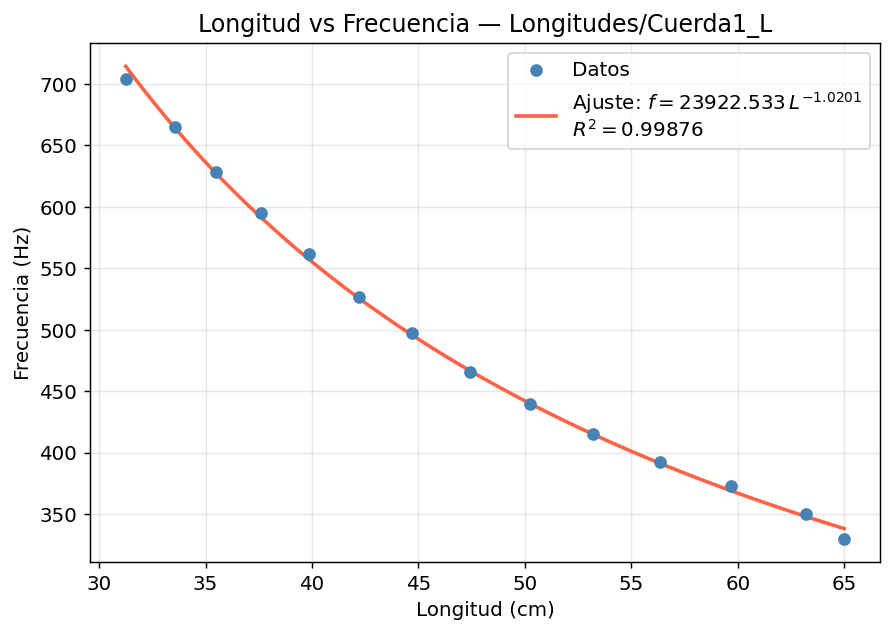

<Figure size 832x624 with 0 Axes>

In [5]:
# ============================================================
# Gráfica: Longitud vs Frecuencia (una cuerda)
# ============================================================
nombre_cuerda = os.path.splitext(ARCHIVO)[0]   

x = df["Longitud"].values.astype(float)
y = df["Frecuencia"].values.astype(float)

a, b, r2 = ajuste_potencial(x, y)

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = a * x_fit**b

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color="steelblue", zorder=3, label="Datos")
ax.plot(x_fit, y_fit, color="tomato", linewidth=2,
        label=f"Ajuste: $f = {a:.3f}\\,L^{{{b:.4f}}}$\n$R^2 = {r2:.5f}$")

ax.set_xlabel("Longitud (cm)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Longitud vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig(f"{nombre_cuerda}_LongitudVsFrecuencia.png", dpi=150)


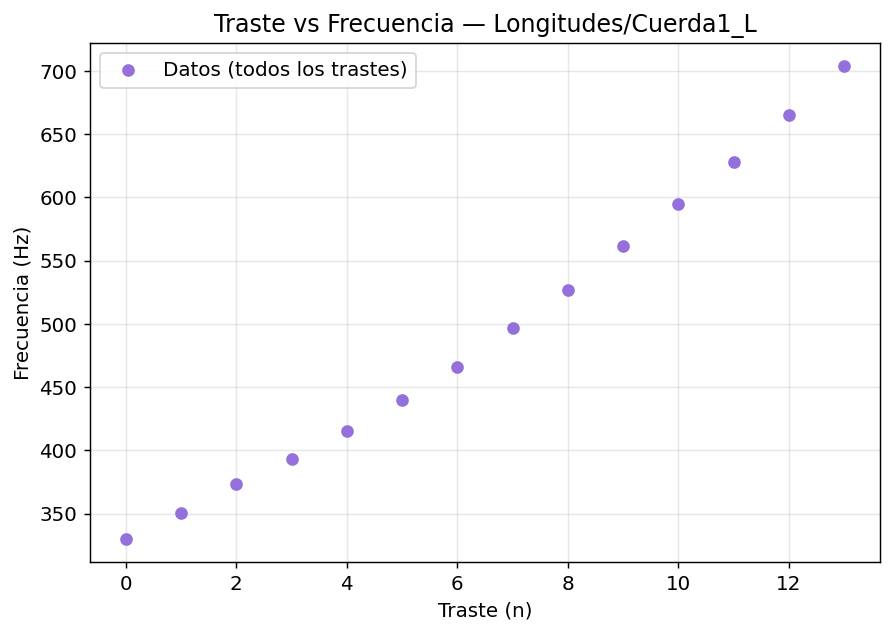

In [6]:
# ============================================================
# Gráfica: Traste vs Frecuencia (una cuerda)
# ============================================================

x_t = df["Traste"].values.astype(float)
y_t = df["Frecuencia"].values.astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_t, y_t,
           color="mediumpurple", zorder=3, label="Datos (todos los trastes)")

ax.set_xlabel("Traste (n)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Traste vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
#   Cargar TODAS las cuerdas        
# ============================================================
archivos = sorted(glob.glob("Longitudes/Cuerda*_L.csv"))
print(f"Archivos encontrados: {archivos}")

dfs = {}
for f in archivos:
    nombre = os.path.splitext(os.path.basename(f))[0]
    tmp = pd.read_csv(f)
    tmp.columns = ["Traste", "Inicio", "Final", "Longitud", "Frecuencia"]
    dfs[nombre] = tmp

print(f"\nTotal de cuerdas cargadas: {len(dfs)}")

Archivos encontrados: ['Longitudes/Cuerda1_L.csv', 'Longitudes/Cuerda2_L.csv', 'Longitudes/Cuerda3_L.csv', 'Longitudes/Cuerda4_L.csv', 'Longitudes/Cuerda5_L.csv', 'Longitudes/Cuerda6_L.csv']

Total de cuerdas cargadas: 6


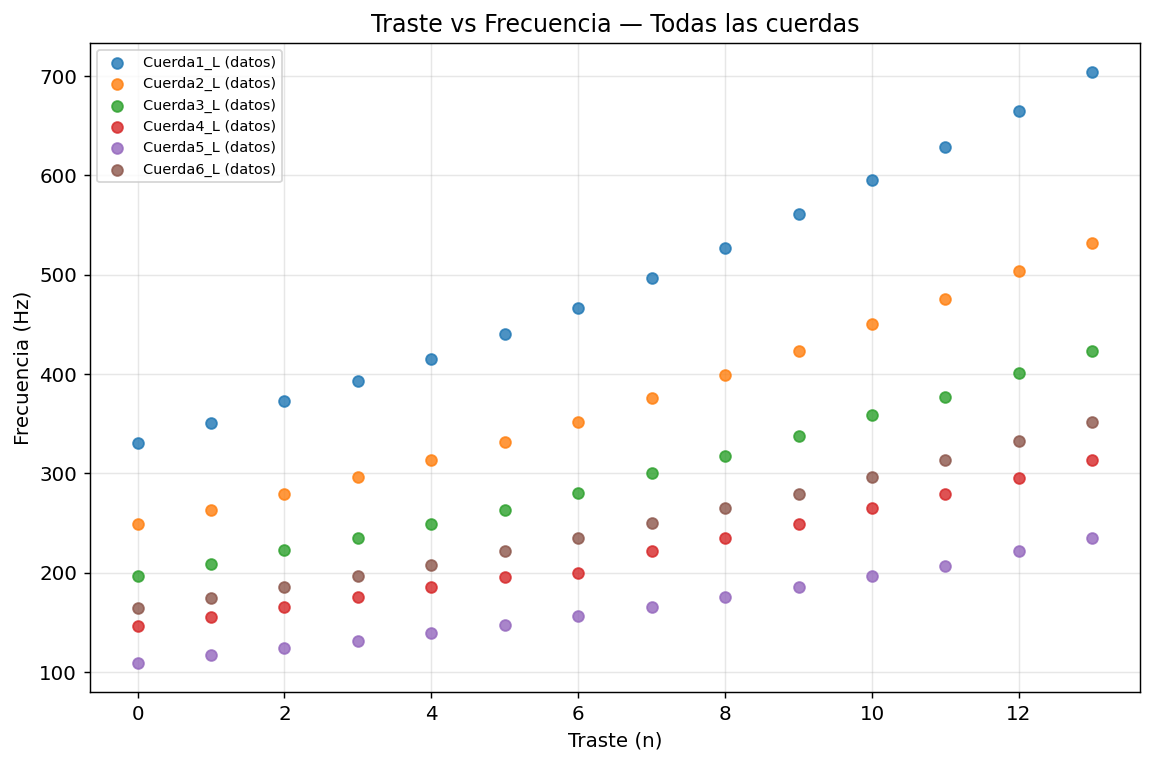

In [8]:
# ============================================================
# Gráfica combinada: Traste vs Frecuencia
# ============================================================

colores = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]

    x_t = data["Traste"].values.astype(float)
    y_t = data["Frecuencia"].values.astype(float)

    ax.scatter(x_t, y_t,
               color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")

ax.set_xlabel("Traste (n)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Traste vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

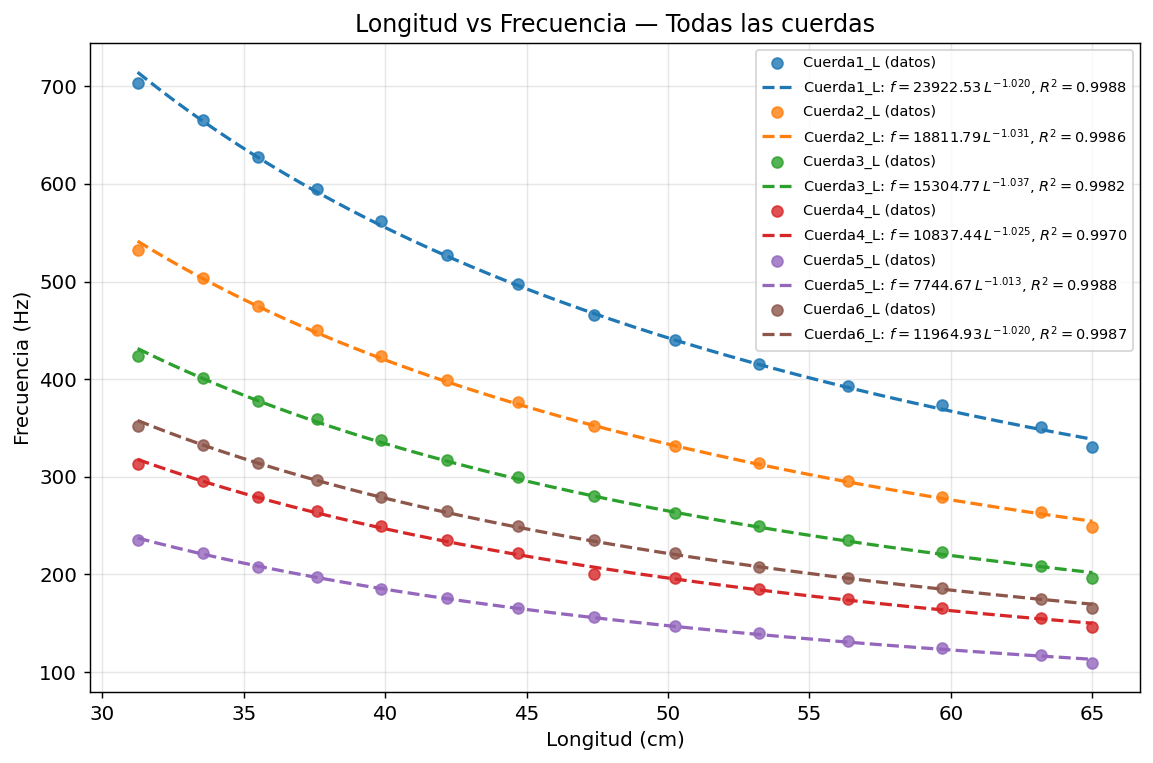

In [9]:
# ============================================================
# Gráfica combinada: Longitud vs Frecuencia 
# ============================================================
colores = plt.cm.tab10.colors   

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]
    x = data["Longitud"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    a, b, r2 = ajuste_potencial(x, y)
    x_fit = np.linspace(x.min(), x.max(), 300)

    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")
    ax.plot(x_fit, a * x_fit**b, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $f={a:.2f}\\,L^{{{b:.3f}}}$, $R^2={r2:.4f}$")

ax.set_xlabel("Longitud (cm)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Longitud vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("Todas_LongitudVsFrecuencia.png", dpi=150)
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_24836/806639821.py:38: SyntaxWarning: invalid escape sequence '\l'
  label=f"{nombre}: $\log(f) = {slope:.3f}\log(L) + {intercept:.2f}$ ($R^2={r2:.4f}$)")
/tmp/ipykernel_24836/806639821.py:38: SyntaxWarning: invalid escape sequence '\l'
  label=f"{nombre}: $\log(f) = {slope:.3f}\log(L) + {intercept:.2f}$ ($R^2={r2:.4f}$)")
/tmp/ipykernel_24836/806639821.py:45: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$\log_{10}$ Longitud (cm)")
/tmp/ipykernel_24836/806639821.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$\log_{10}$ Frecuencia (Hz

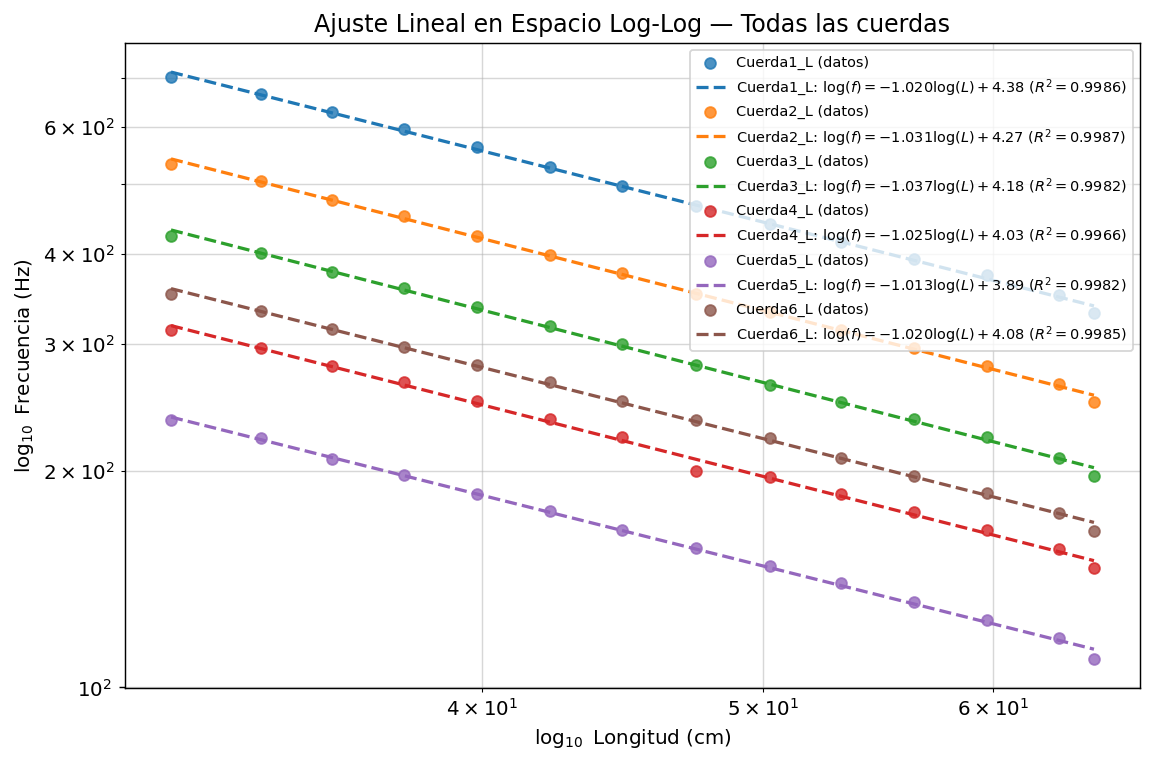

In [10]:
# =====================================================================
# Gráfica Log-Log: Longitud vs Frecuencia (Lineal)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

colores = plt.cm.tab10.colors 

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]
    # Aseguramos que los datos sean float y filtramos valores <= 0 para evitar errores en log
    x = data["Longitud"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    # Cálculo del ajuste lineal en espacio logarítmico
    # log(y) = b * log(x) + log(a)
    log_x = np.log10(x)
    log_y = np.log10(y)
    
    # Ajuste polinomial de grado 1 (recta)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    # Coeficiente de correlación R²
    y_pred = slope * log_x + intercept
    r2 = 1 - (np.sum((log_y - y_pred)**2) / np.sum((log_y - np.mean(log_y))**2))

    # Graficamos los puntos en escala logarítmica
    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")
    
    # Graficamos la recta de ajuste
    # Usamos x.min y x.max para que la línea cubra el rango de datos
    x_fit = np.geomspace(x.min(), x.max(), 100)
    y_fit = (10**intercept) * (x_fit**slope)
    
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $\log(f) = {slope:.3f}\log(L) + {intercept:.2f}$ ($R^2={r2:.4f}$)")

# Configuración de escalas logarítmicas
ax.set_xscale('log')
ax.set_yscale('log')

# Etiquetas y formato
ax.set_xlabel("$\log_{10}$ Longitud (cm)")
ax.set_ylabel("$\log_{10}$ Frecuencia (Hz)")
ax.set_title("Ajuste Lineal en Espacio Log-Log — Todas las cuerdas")
ax.grid(True, which="both", ls="-", alpha=0.5)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.savefig("LogLog_LongitudVsFrecuencia.png", dpi=150)
plt.show()

## Estudio Tensiones

Se utilizan las **6 cuerdas** de una guitarra. Para cada cuerda se gira la clavija a distintos ángulos acumulados y se cuelga **la misma masa** `m` en el centro de la cuerda, registrando el desplazamiento vertical `y` resultante.

| Ángulo de clavija | Descripción |
|---|---|
| 0° | Cuerda afinada (referencia) |
| +90° | Tensionada 90° respecto a la afinación |
| +180° | Tensionada 180° respecto a la afinación |
| −90° | Destensionada 90° respecto a la afinación |
| −180° | Destensionada 180° respecto a la afinación |
| ... | ... |


---
**Lógica física:** a mayor tensión en la cuerda → menor `y` al colgar el mismo peso → mayor `T` calculada.

In [ ]:
# ============================================================
# Cargar datos de UNA cuerda específica
# ============================================================
ARCHIVO = "Tensiones/Cuerda1_T.csv" 

df = pd.read_csv(ARCHIVO)

# Eliminar espacios normales Y espacios no rompibles (\xa0)
df.columns = df.columns.str.replace(r'[\s\xa0]+', '', regex=True)

# Verificar nombres resultantes
print("Columnas detectadas:", df.columns.tolist())

df.columns = ["Angulo", "Tension", "Frecuencia"]

print(df)

In [ ]:
# ============================================================
# Ajuste potencial 
# ============================================================
def ajuste_potencial(x, y):
    """
    Ajusta y = a * x^b usando regresión lineal en escala log-log.
    Solo funciona con x > 0 e y > 0.
    Retorna (a, b, R²).
    """
    log_x = np.log(x)
    log_y = np.log(y)
    coeffs = np.polyfit(log_x, log_y, 1)   # [b, log(a)]
    b = coeffs[0]
    a = np.exp(coeffs[1])

    y_pred = a * x**b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return a, b, r2

In [ ]:
# ============================================================
# Gráfica: Tensión vs Frecuencia (UNA cuerda)
# ============================================================
nombre_cuerda = os.path.splitext(ARCHIVO)[0]  

x = df["Tension"].values.astype(float)
y = df["Frecuencia"].values.astype(float)

a, b, r2 = ajuste_potencial(x, y)

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = a * x_fit**b

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(x, y, color="steelblue", zorder=3, s=60, label="Datos")
ax.plot(x_fit, y_fit, color="tomato", linewidth=2,
        label=f"Ajuste: $f = {a:.4f}\\,T^{{{b:.4f}}}$\n$R^2 = {r2:.5f}$")

ax.set_xlabel("Tensión (N)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Tensión vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{nombre_cuerda}_TensionVsFrecuencia.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# Cargar TODAS las cuerdas
# ============================================================
archivos = sorted(glob.glob("Tensiones/Cuerda*_T.csv"))
print(f"Archivos encontrados: {archivos}")

dfs = {}
for f in archivos:
    nombre = os.path.splitext(os.path.basename(f))[0]
    
    # Leer sin asumir tipos, con engine flexible
    tmp = pd.read_csv(f, dtype=str, encoding_errors='replace')
    
    # Limpiar nombres de columna (espacios normales, \xa0, etc.)
    tmp.columns = tmp.columns.str.replace(r'[\s\xa0\u00a0]+', '', regex=True)
    
    # Renombrar por posición (más seguro que por nombre)
    tmp.columns = ["Angulo", "Tension", "Frecuencia"]
    
    # Convertir a numérico, cualquier basura se vuelve NaN y se elimina
    tmp["Tension"]    = pd.to_numeric(tmp["Tension"].str.replace(r'[\xa0\u00a0]', '', regex=True), errors='coerce')
    tmp["Frecuencia"] = pd.to_numeric(tmp["Frecuencia"].str.replace(r'[\xa0\u00a0]', '', regex=True), errors='coerce')
    tmp["Angulo"]     = pd.to_numeric(tmp["Angulo"].str.replace(r'[\xa0\u00a0]', '', regex=True), errors='coerce')
    
    # Eliminar filas donde Tension o Frecuencia sean NaN
    tmp.dropna(subset=["Tension", "Frecuencia"], inplace=True)
    tmp.reset_index(drop=True, inplace=True)
    
    print(f"\n{nombre} — {len(tmp)} filas válidas")
    print(tmp)
    
    dfs[nombre] = tmp

print(f"\nTotal de cuerdas cargadas: {len(dfs)}")

In [ ]:
# ============================================================
# Gráfica combinada: Tensión vs Frecuencia (TODAS)
# ============================================================ 

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]

    x = data["Tension"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    a, b, r2 = ajuste_potencial(x, y)
    x_fit = np.linspace(x.min(), x.max(), 300)

    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, s=55,
               label=f"{nombre} (datos)")
    ax.plot(x_fit, a * x_fit**b, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $f={a:.3f}\\,T^{{{b:.4f}}}$, $R^2={r2:.4f}$")

ax.set_xlabel("Tensión (N)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Tensión vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.0, 0.8))
plt.tight_layout()
plt.savefig("Todas_TensionVsFrecuencia.png", dpi=150)
plt.show()

In [ ]:
# =====================================================================
# Gráfica Log-Log: Tensión vs Frecuencia (Lineal)
# =====================================================================

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]
    
    # Extraemos datos asegurando que sean numéricos
    x = data["Tension"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    # Transformación logarítmica para el ajuste lineal
    log_x = np.log10(x)
    log_y = np.log10(y)
    
    # Ajuste lineal: log(y) = slope * log(x) + intercept
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    # Cálculo del R² en el espacio logarítmico
    y_pred = slope * log_x + intercept
    r2 = 1 - (np.sum((log_y - y_pred)**2) / np.sum((log_y - np.mean(log_y))**2))

    # Puntos experimentales
    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, s=55, label=f"{nombre} (datos)")
    
    # Generamos la curva de ajuste para escala logarítmica
    x_fit = np.geomspace(x.min(), x.max(), 100)
    y_fit = (10**intercept) * (x_fit**slope)
    
    # Graficamos la línea de ajuste
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $\log(f) = {slope:.3f}\log(T) + {intercept:.2f}$ ($R^2={r2:.4f}$)")

# Configuración de escalas logarítmicas en ambos ejes
ax.set_xscale('log')
ax.set_yscale('log')

# Etiquetas con notación matemática
ax.set_xlabel("Tensión $T$ (N) [Escala Log]")
ax.set_ylabel("Frecuencia $f$ (Hz) [Escala Log]")
ax.set_title("Ajuste Lineal en Espacio Log-Log: Tensión vs Frecuencia")

# Grilla técnica para escalas logarítmicas
ax.grid(True, which="both", ls="-", alpha=0.4)

# Ajuste de la leyenda para que no tape los datos
ax.legend(fontsize=5, loc='best')

plt.tight_layout()
plt.savefig("LogLog_TensionVsFrecuencia.png", dpi=150)
plt.show()

## Estudio Densidad

In [ ]:
# ============================================================
# Cargar datos
# ============================================================
ARCHIVO = "Densidades/Densidades.csv"

df = pd.read_csv(ARCHIVO, index_col=0)
df.columns = df.columns.str.strip()
df.columns = ["Densidad", "Frecuencia"]
df.index   = df.index.str.strip()

df["Densidad"]   = pd.to_numeric(df["Densidad"],   errors="coerce")
df["Frecuencia"] = pd.to_numeric(df["Frecuencia"], errors="coerce")
df.dropna(inplace=True)

print(df)

In [ ]:
# ============================================================
#  Ajuste potencial
# ============================================================
def ajuste_potencial(x, y):
    """
    Ajusta y = a * x^b en escala log-log.
    Retorna (a, b, R²).
    """
    log_x  = np.log(x)
    log_y  = np.log(y)
    coeffs = np.polyfit(log_x, log_y, 1)   
    b = coeffs[0]
    a = np.exp(coeffs[1])

    y_pred = a * x**b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2     = 1 - ss_res / ss_tot

    return a, b, r2

In [ ]:
# ============================================================
# Gráfica: Densidad vs Frecuencia (todas las cuerdas)
# ============================================================
x = df["Densidad"].values
y = df["Frecuencia"].values

a, b, r2 = ajuste_potencial(x, y)

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = a * x_fit**b

colores = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 5.5))

# Scatter con etiqueta por cuerda
for i, (cuerda, row) in enumerate(df.iterrows()):
    ax.scatter(row["Densidad"], row["Frecuencia"],
               color=colores[i % len(colores)],
               s=80, zorder=4, label=cuerda)

# Línea de tendencia potencial
ax.plot(x_fit, y_fit, color="black", linewidth=2, linestyle="--",
        label=f"Ajuste: $f = {a:.4f}\\,\\mu^{{{b:.4f}}}$\n$R^2 = {r2:.5f}$")

ax.set_xlabel("Densidad lineal $\\mu$ (kg/m)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Densidad lineal vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.savefig("Densidad_vs_Frecuencia.png", dpi=150)
plt.show()

## Regresión Simbólica

In [ ]:
df = pd.read_csv("Dataset_Filtrado.csv")  

# Verificación rápida
print(df.head())
print(df.dtypes)
print(f"Total de filas: {len(df)}")

In [ ]:
# Variables independientes
X = df[["Tension", "Densidad", "Longitud"]].values

# Variable objetivo
y = df["Frecuencia"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Rango de frecuencias:", y.min(), "–", y.max())

In [ ]:
from pysr import PySRRegressor

model = PySRRegressor(
    niterations=300, 
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt"], 
    constraints={'/': (-1, 9), 'sqrt': 9}, 
    nested_constraints={"sqrt": {"sqrt": 0}}, 
    maxsize=12, 
    populations=30,
    variable_names=["Tension", "Densidad", "Longitud"], 
    model_selection="best",
    verbosity=1,
    random_state=42,
)

model.fit(X, y)

In [ ]:
print(model)

In [ ]:
# Obtener la mejor ecuación como expresión SymPy
best_eq = model.sympy()

# Imprimir en LaTeX
latex_str = sp.latex(best_eq)
print("LaTeX:")
print(latex_str)

# Si estás en Jupyter, renderiza directamente
from IPython.display import display, Math
display(Math(latex_str))

Se realizó una limpieza del Dataset, buscando eliminar los datos de tensiones que se ecnontraban alejados del ajuste potencial de 0.5

In [ ]:
df = pd.read_csv("Dataset_Filtrado.csv")  

# Verificación rápida
print(df.head())
print(df.dtypes)
print(f"Total de filas: {len(df)}")

In [ ]:
# Variables independientes
X = df[["Tension", "Densidad", "Longitud"]].values

# Variable objetivo
y = df["Frecuencia"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Rango de frecuencias:", y.min(), "–", y.max())

In [ ]:
from pysr import PySRRegressor

model = PySRRegressor(
    niterations=300, 
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt"], 
    constraints={'/': (-1, 9), 'sqrt': 9}, 
    nested_constraints={"sqrt": {"sqrt": 0}}, 
    maxsize=12, 
    populations=30,
    variable_names=["Tension", "Densidad", "Longitud"], 
    model_selection="best",
    verbosity=1,
    random_state=42,
)

model.fit(X, y)

In [ ]:
print(model)

In [ ]:
# Obtener la mejor ecuación como expresión SymPy
best_eq = model.sympy()

# Imprimir en LaTeX
latex_str = sp.latex(best_eq)
print("LaTeX:")
print(latex_str)

# Si estás en Jupyter, renderiza directamente
from IPython.display import display, Math
display(Math(latex_str))

Se realiza una linealización del modelo buscando que la regresion logré encontrar la realacion de amnera mas sencilla

$$\boxed{f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}}$$

Buscando entonces:

$$\boxed{f^2 = 0.25 \cdot \frac{T}{\mu \cdot L^2}}$$


In [ ]:
df_limpio = pd.read_csv('Dataset.csv')

# Variables independientes (Features)
X = df_limpio[['T', 'D', 'L']]

# Variable objetivo (Target) elevada al cuadrado
y = df_limpio['Frecuencia']**2

print("Preparación completada:")
print(f"- Registros cargados: {len(df_limpio)}")
print(f"- Columnas de entrada: {list(X.columns)}")

In [ ]:
from pysr import PySRRegressor

# Configuración para buscar la estructura f^2 = (1/4) * T / (mu * L^2)
model = PySRRegressor(
    niterations=1000,            # Mayor profundidad de búsqueda
    binary_operators=["*", "/"],  # Operadores fundamentales para leyes de potencias
    unary_operators=[],           # No se requieren operadores unarios para el modelo f^2
    constraints={'/': (-1, 9)},   # Evita divisiones excesivamente complejas
    maxsize=12,                   # Restringe a una ecuación compacta y elegante
    variable_names=["T", "D", "L"],
    model_selection="best",       # Elige el modelo con mejor equilibrio error/complejidad
    loss="loss(prediction, target) = (prediction - target)^2",
    random_state=42,
    verbosity=1
)

# Ajuste del modelo
model.fit(X, y)

In [ ]:
import sympy as sp
from IPython.display import display, Math

best_model = model.get_best()
equation_sympy = best_model.sympy_format


simplified_eq = sp.simplify(equation_sympy)


latex_str = sp.latex(simplified_eq)


print("Resultado de la Regresión Simbólica para f²:")
display(Math(rf"f^2 = {latex_str}"))

Probamos el desempeño con la totalidad de los datos

In [ ]:
df_limpio = pd.read_csv('Dataset.csv')

# Variables independientes (Features)
X = df_limpio[['T', 'D', 'L']]

# Variable objetivo (Target) elevada al cuadrado
y = df_limpio['Frecuencia']**2

print("Preparación completada:")
print(f"- Registros cargados: {len(df_limpio)}")
print(f"- Columnas de entrada: {list(X.columns)}")

In [ ]:
# Configuración para buscar la estructura f^2 = (1/4) * T / (mu * L^2)
model = PySRRegressor(
    niterations=1000,            # Mayor profundidad de búsqueda
    binary_operators=["*", "/"],  # Operadores fundamentales para leyes de potencias
    unary_operators=[],           # No se requieren operadores unarios para el modelo f^2
    constraints={'/': (-1, 9)},   # Evita divisiones excesivamente complejas
    maxsize=12,                   # Restringe a una ecuación compacta y elegante
    variable_names=["T", "D", "L"],
    model_selection="best",       # Elige el modelo con mejor equilibrio error/complejidad
    loss="loss(prediction, target) = (prediction - target)^2",
    random_state=42,
    verbosity=1
)

# Ajuste del modelo
model.fit(X, y)

In [ ]:
import sympy as sp
from IPython.display import display, Math

best_model = model.get_best()
equation_sympy = best_model.sympy_format


simplified_eq = sp.simplify(equation_sympy)


latex_str = sp.latex(simplified_eq)


print("Resultado de la Regresión Simbólica para f²:")
display(Math(rf"f^2 = {latex_str}"))